In [ ]:
# Imports
from pathlib import Path
import io
import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
import urllib.request
import zstandard as zstd
import chess
import chess.pgn
import chess.engine

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  median_absolute_error,
  r2_score,
)

from xgboost import XGBRegressor
import joblib

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [2]:
# Configuration
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = DATA_DIR / "models"

for path in [RAW_DIR, PROCESSED_DIR, MODEL_DIR]:
  path.mkdir(parents=True, exist_ok=True)

# Lichess monthly database file.
year = 2014
month = 4

filename = f"lichess_db_standard_rated_{year}-{month:02d}.pgn.zst"
url = f"https://database.lichess.org/standard/{filename}"
zst_path = RAW_DIR / filename

# Keep this modest. PGN parsing is cheap; Stockfish analysis is not.
MAX_GAMES_TO_READ = 36_000
N_GAMES_ENGINE = 6_000

# Analyze only the first N plies of each game. 30 plies = 15 full moves.
# Increasing this improves signal but scales linearly in runtime.
ENGINE_MAX_PLIES = 30
ENGINE_DEPTH = 8
ENGINE_THREADS = 1
ENGINE_HASH_MB = 128

# Cap extreme mate-conversion losses so one forced mate does not dominate.
CP_LOSS_CLIP = 2_000
MATE_SCORE = 100_000

# Change this manually if shutil.which("stockfish") does not find your binary.
STOCKFISH_PATH = os.environ.get("STOCKFISH_PATH") or shutil.which("stockfish")

print("PGN URL:", url)
print("Local path:", zst_path)
print("Stockfish path:", STOCKFISH_PATH)

PGN URL: https://database.lichess.org/standard/lichess_db_standard_rated_2014-04.pgn.zst
Local path: data/raw/lichess_db_standard_rated_2014-04.pgn.zst
Stockfish path: /opt/homebrew/bin/stockfish


In [3]:
# Download PGN file
if not zst_path.exists():
  print(f"Downloading {filename}...")
  urllib.request.urlretrieve(url, zst_path)
  print("Done.")
else:
  print("File already exists.")

File already exists.


In [4]:
# PGN streaming helpers
def iter_pgn_games_from_zst(zst_path, max_games=None):
  """Yield python-chess Game objects from a compressed Lichess PGN file."""
  dctx = zstd.ZstdDecompressor()

  with open(zst_path, "rb") as compressed:
    with dctx.stream_reader(compressed) as reader:
      text_stream = io.TextIOWrapper(reader, encoding="utf-8")

      n_games = 0
      while True:
        game = chess.pgn.read_game(text_stream)

        if game is None:
          break

        yield game
        n_games += 1

        if max_games is not None and n_games >= max_games:
          break


def parse_rating(value):
  """Parse Lichess rating headers, keeping provisional '?' information separate."""
  if value is None:
    return np.nan, False

  text = str(value).strip()
  is_provisional = text.endswith("?")
  text = text.replace("?", "")

  try:
    return float(text), is_provisional
  except ValueError:
    return np.nan, is_provisional


def game_to_light_record(game):
  """Extract metadata plus SAN/UCI moves without doing engine analysis yet."""
  headers = game.headers
  board = game.board()

  moves_san = []
  moves_uci = []

  for move in game.mainline_moves():
    moves_san.append(board.san(move))
    moves_uci.append(move.uci())
    board.push(move)

  white_elo, white_provisional = parse_rating(headers.get("WhiteElo"))
  black_elo, black_provisional = parse_rating(headers.get("BlackElo"))

  return {
    "event": headers.get("Event"),
    "site": headers.get("Site"),
    "date": headers.get("UTCDate", headers.get("Date")),
    "time": headers.get("UTCTime"),
    "white": headers.get("White"),
    "black": headers.get("Black"),
    "result": headers.get("Result"),
    "white_elo": white_elo,
    "black_elo": black_elo,
    "white_provisional": white_provisional,
    "black_provisional": black_provisional,
    "white_rating_diff": headers.get("WhiteRatingDiff"),
    "black_rating_diff": headers.get("BlackRatingDiff"),
    "eco": headers.get("ECO"),
    "opening": headers.get("Opening"),
    "time_control": headers.get("TimeControl"),
    "termination": headers.get("Termination"),
    "num_plies": len(moves_uci),
    "num_full_moves": len(moves_uci) / 2,
    "moves_san": " ".join(moves_san),
    "moves_uci": " ".join(moves_uci),
  }

In [5]:
metadata_path = PROCESSED_DIR / (
  f"lichess_{year}_{month:02d}_metadata_first_{MAX_GAMES_TO_READ}.parquet"
)

if metadata_path.exists():
  df_raw = pd.read_parquet(metadata_path)
  print(f"Loaded cached metadata: {metadata_path}")
else:
  records = []
  game_iter = iter_pgn_games_from_zst(
    zst_path,
    max_games=MAX_GAMES_TO_READ,
  )

  for game in tqdm(game_iter, total=MAX_GAMES_TO_READ):
    records.append(game_to_light_record(game))

  df_raw = pd.DataFrame(records)
  df_raw.to_parquet(metadata_path, index=False)
  print(f"Wrote: {metadata_path}")

df_raw.head()

Loaded cached metadata: data/processed/lichess_2014_04_metadata_first_36000.parquet


,event,site,date,time,white,black,result,white_elo,black_elo,white_provisional,black_provisional,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san,moves_uci
0,Rated Blitz game,https://lichess.org/ijPYwgVx,2014.03.31,22:01:18,ljubisa2810,amirmahdi,1-0,1806.0,1644.0,False,False,+7,-7,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,22.5,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...,e2e4 e7e6 g1f3 c7c5 c2c3 b7b6 f1b5 c8b7 e1g1 b...
1,Rated Blitz game,https://lichess.org/y5MMbLnm,2014.03.31,22:00:10,Katapult,dododa,1-0,1905.0,1799.0,False,False,+8,-8,B08,Pirc Defense: Classical Variation,180+0,Normal,61,30.5,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...,e2e4 d7d6 g1f3 g7g6 d2d4 f8g7 b1c3 g8f6 c1g5 e...
2,Rated Blitz game,https://lichess.org/hXbjsQue,2014.03.31,22:00:09,slansson,chycha,1-0,1469.0,1500.0,False,False,+11,-13,C41,Philidor Defense #3,360+0,Time forfeit,95,47.5,e4 e5 Nf3 d6 Bc4 h6 c3 a6 d4 b5 Bb3 Nf6 dxe5 N...,e2e4 e7e5 g1f3 d7d6 f1c4 h7h6 c2c3 a7a6 d2d4 b...
3,Rated Blitz game,https://lichess.org/kf4hwzAq,2014.03.31,22:00:18,NIS,paiaka,1-0,1131.0,1063.0,False,False,+9,-11,C41,Philidor Defense #2,300+0,Time forfeit,13,6.5,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3,e2e4 e7e5 g1f3 d7d6 b1c3 c8g4 f1b5 c7c6 b5e2 g...
4,Rated Classical game,https://lichess.org/ZGMLO460,2014.03.31,22:00:33,zinder2,mart1975,1-0,1724.0,1318.0,False,False,+3,-2,B00,Owen Defense,300+8,Normal,41,20.5,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...,e2e4 b7b6 d2d4 c8b7 b1c3 g7g6 g1f3 f8g7 f1c4 d...


In [6]:
print(df_raw.shape)
df_raw.info()

(36000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event              36000 non-null  str    
 1   site               36000 non-null  str    
 2   date               36000 non-null  str    
 3   time               36000 non-null  str    
 4   white              36000 non-null  str    
 5   black              36000 non-null  str    
 6   result             36000 non-null  str    
 7   white_elo          36000 non-null  float64
 8   black_elo          35999 non-null  float64
 9   white_provisional  36000 non-null  bool   
 10  black_provisional  36000 non-null  bool   
 11  white_rating_diff  35310 non-null  str    
 12  black_rating_diff  35310 non-null  str    
 13  eco                36000 non-null  str    
 14  opening            36000 non-null  str    
 15  time_control       36000 non-null  str    
 16  termination        36

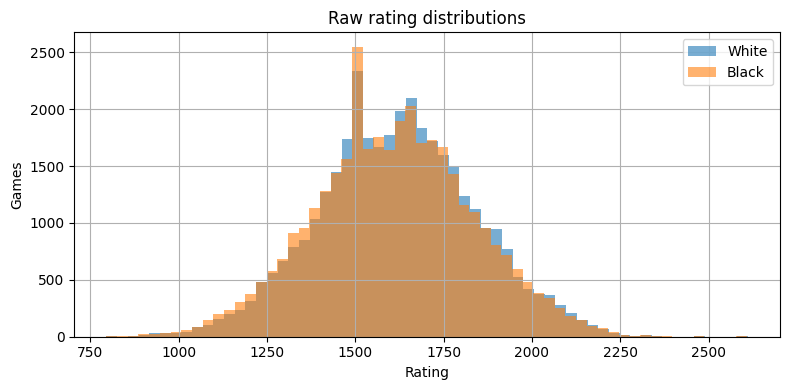

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_raw["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Raw rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

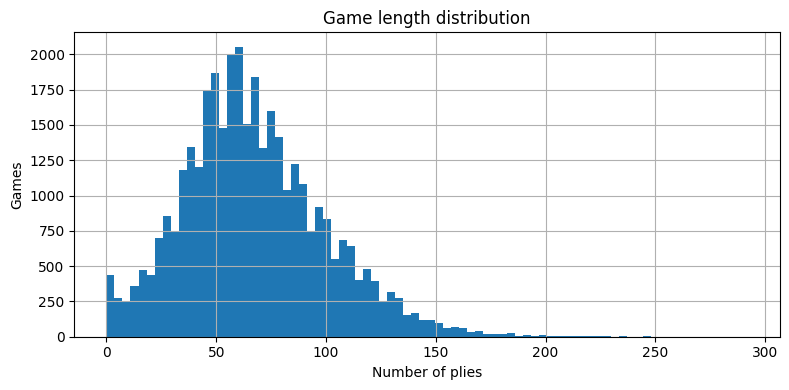

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["num_plies"].hist(bins=80, ax=ax)
ax.set_xlabel("Number of plies")
ax.set_ylabel("Games")
ax.set_title("Game length distribution")
plt.tight_layout()
plt.show()

In [13]:
print("Results:")
display(df_raw["result"].value_counts(dropna=False).to_frame("count"))

print("\nTermination:")
display(df_raw["termination"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nTime controls:")
display(df_raw["time_control"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nOpenings:")
display(df_raw["opening"].value_counts(dropna=False).head(20).to_frame("count"))

Results:


,count
result,
1-0,18305
0-1,16474
1/2-1/2,1221



Termination:


,count
termination,
Normal,24004
Time forfeit,11989
Rules infraction,7



Time controls:


,count
time_control,
60+0,4013
300+0,3746
180+0,2779
120+0,2198
300+8,1986
600+0,1433
240+0,1365
0+1,1364
60+1,1137



Openings:


,count
opening,
Van't Kruijs Opening,1015
Modern Defense,680
Horwitz Defense,654
Scandinavian Defense: Mieses-Kotroc Variation,559
French Defense: Knight Variation,557
Owen Defense,554
Caro-Kann Defense,547
Bishop's Opening,510
Sicilian Defense: Bowdler Attack,495


In [14]:
# Filter out data 
MIN_PLIES = 20
REMOVE_EXACT_1500 = True
REMOVE_PROVISIONAL = True

valid_mask = (
  df_raw["white_elo"].notna()
  & df_raw["black_elo"].notna()
  & df_raw["result"].isin(["1-0", "0-1", "1/2-1/2"])
  & df_raw["moves_uci"].notna()
  & df_raw["num_plies"].ge(MIN_PLIES)
)

if REMOVE_EXACT_1500:
  valid_mask &= ~(
    df_raw["white_elo"].eq(1500)
    | df_raw["black_elo"].eq(1500)
  )

if REMOVE_PROVISIONAL:
  valid_mask &= ~(
    df_raw["white_provisional"].fillna(False)
    | df_raw["black_provisional"].fillna(False)
  )

df_games = df_raw.loc[valid_mask].copy()

print("Rows before filtering:", len(df_raw))
print("Rows after filtering: ", len(df_games))
print("Removed:              ", len(df_raw) - len(df_games))

df_games[["white_elo", "black_elo", "num_plies"]].describe()

Rows before filtering: 36000
Rows after filtering:  32549
Removed:               3451


,white_elo,black_elo,num_plies
count,32549.000000,32549.000000,32549.00000
mean,1629.003810,1621.022796,70.76285
std,221.709161,225.635519,30.21533
min,884.000000,850.000000,20.00000
25%,1476.000000,1467.000000,49.00000
50%,1632.000000,1625.000000,66.00000
75%,1776.000000,1771.000000,88.00000
max,2611.000000,2608.000000,292.00000


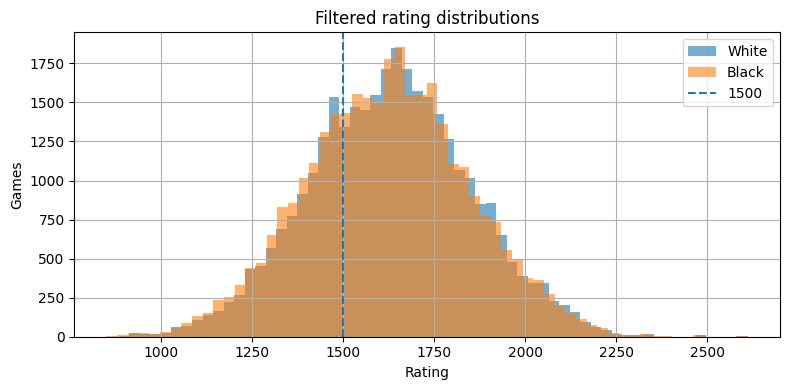

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
df_games["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_games["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.axvline(1500, linestyle="--", label="1500")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Filtered rating distributions")
ax.legend()
plt.tight_layout()
plt.show()